In [1]:
# Here we load all packages needed for preprocessing, training, and analysis.
# I am keeping them together so later cells stay focused on logic only.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import torch.optim as optim
from sklearn.metrics import accuracy_score
from torch.utils.data import Subset
from torchvision import transforms
from sklearn.metrics import confusion_matrix

In [2]:
# In this step we define the global seed function and apply it.
# Same seed is set for python, numpy, and torch for reproducibility.
# So model comparisons become fair across different runs.
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None (running on CPU)")

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
# Now we define dataset paths and load the NPZ files from disk.
# File keys are printed to verify expected arrays are present.
# Device info is also checked so we know cpu/gpu execution target.
DATA_DIR = Path("DL_PA2/DL_PA2/processed_data")
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

train_npz = np.load(TRAIN_FILE, allow_pickle=True)
test_npz = np.load(TEST_FILE, allow_pickle=True)

print("Train file keys:", train_npz.files)
print("Test file keys:", test_npz.files)

Train file keys: ['x_train', 'y_train', 'class_names']
Test file keys: ['test_images']


# Visualizing the Data 

In [4]:
# This cell extracts x_train, y_train, class names, and x_test arrays.
# Shapes and dtypes are printed as a quick sanity check.
# This is the raw input used by all next preprocessing steps.
x_train = train_npz["x_train"]        
y_train = train_npz["y_train"]        
class_names = train_npz["class_names"]  
x_test = test_npz["test_images"]      

print("x_train shape:", x_train.shape, "| dtype:", x_train.dtype)
print("y_train shape:", y_train.shape, "| dtype:", y_train.dtype)
print("x_test shape :", x_test.shape,  "| dtype:", x_test.dtype)
print("Num classes  :", len(class_names))
print("Class names  :", class_names)

x_train shape: (60000, 784) | dtype: uint8
y_train shape: (60000,) | dtype: int64
x_test shape : (15000, 784) | dtype: uint8
Num classes  : 15
Class names  : ['apple' 'baseballbat' 'basketball' 'clock' 'compass' 'cookie' 'donut'
 'ladder' 'mountain' 'pizza' 'rabbit' 'soccerball' 'spider' 't-shirt'
 'wheel']


Class balance (raw train set):
 0 | apple        | count =  4000 |   6.67%
 1 | baseballbat  | count =  4000 |   6.67%
 2 | basketball   | count =  4000 |   6.67%
 3 | clock        | count =  4000 |   6.67%
 4 | compass      | count =  4000 |   6.67%
 5 | cookie       | count =  4000 |   6.67%
 6 | donut        | count =  4000 |   6.67%
 7 | ladder       | count =  4000 |   6.67%
 8 | mountain     | count =  4000 |   6.67%
 9 | pizza        | count =  4000 |   6.67%
10 | rabbit       | count =  4000 |   6.67%
11 | soccerball   | count =  4000 |   6.67%
12 | spider       | count =  4000 |   6.67%
13 | t-shirt      | count =  4000 |   6.67%
14 | wheel        | count =  4000 |   6.67%


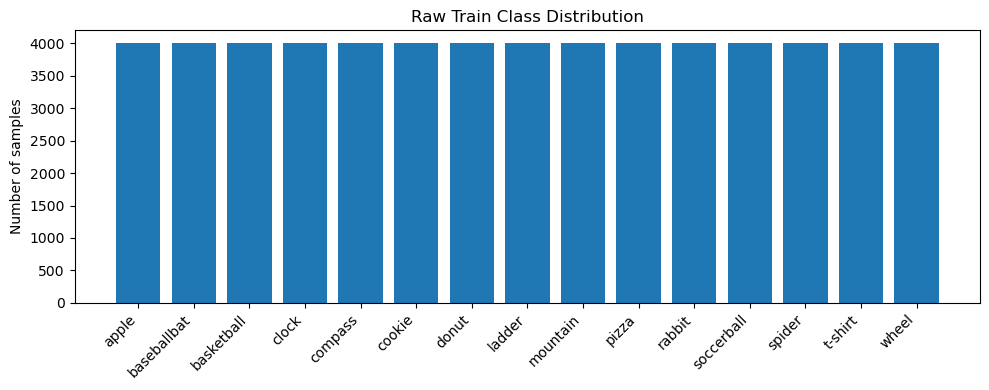

In [5]:
# Here we inspect class balance in the raw training labels.
# Counts and percentages are printed for each class id.
# A bar chart is plotted to visualize any class skew quickly.
labels = y_train
num_classes = len(class_names)
counts = np.bincount(labels, minlength=num_classes)
percentages = counts / counts.sum() * 100

print("Class balance (raw train set):")
for i, (name, c, p) in enumerate(zip(class_names, counts, percentages)):
    print(f"{i:2d} | {str(name):12s} | count = {c:5d} | {p:6.2f}%")

plt.figure(figsize=(10, 4))
plt.bar(range(num_classes), counts)
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.ylabel("Number of samples")
plt.title("Raw Train Class Distribution")
plt.tight_layout()
plt.show()

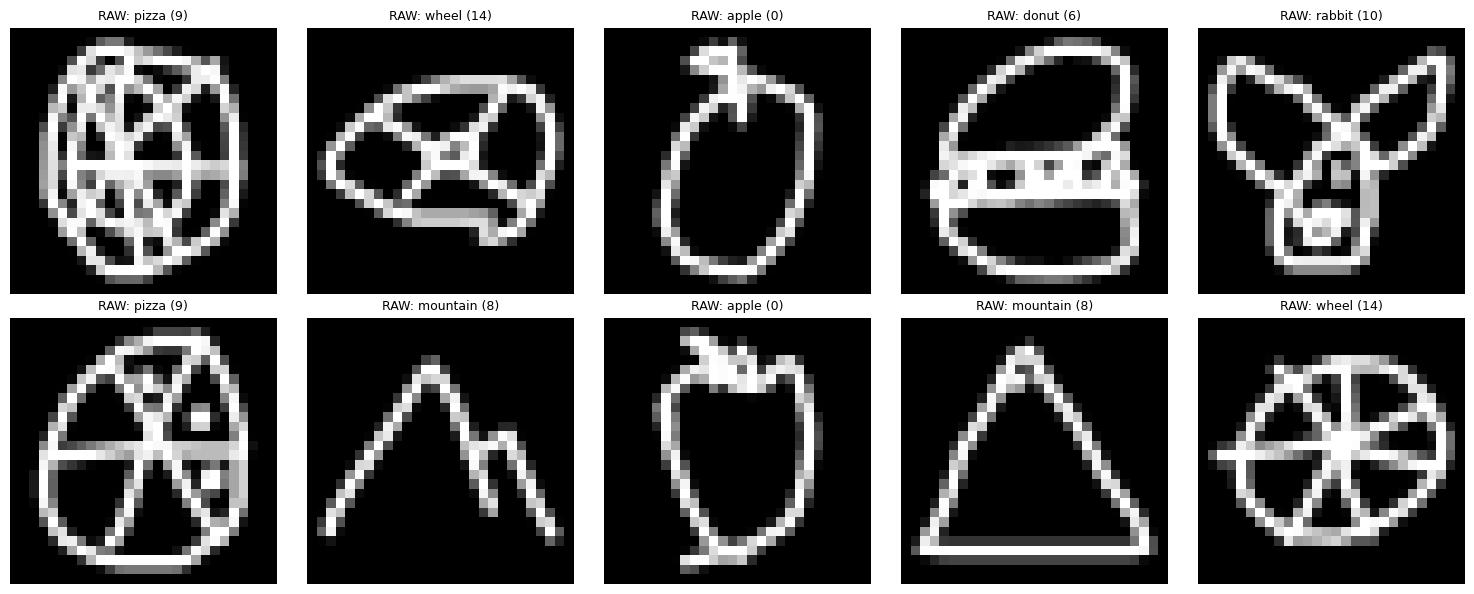

In [6]:
# In this cell we keep raw copies of images before normalization.
# Then we plot random samples to inspect drawing quality and labels.
# This helps us see the data state before any scaling.
x_train_raw = x_train.copy()
x_test_raw = x_test.copy()

num_to_show = 10
rng = np.random.default_rng()  
random_indices = rng.choice(len(x_train_raw), size=num_to_show, replace=False)

plt.figure(figsize=(15, 6))
for plot_i, sample_idx in enumerate(random_indices):
    img = x_train_raw[sample_idx].reshape(28, 28)
    label_id = int(y_train[sample_idx])
    label_name = str(class_names[label_id])

    plt.subplot(2, 5, plot_i + 1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(f"RAW: {label_name} ({label_id})", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
# Now we normalize train and test pixels from 0-255 to 0-1.
# This scaling improves optimization stability in neural networks.
x_train = x_train_raw.astype(np.float32) / 255.0
x_test = x_test_raw.astype(np.float32) / 255.0

print("Train min/max:", x_train.min(), x_train.max())
print("Test  min/max:", x_test.min(), x_test.max())

Train min/max: 0.0 1.0
Test  min/max: 0.0 1.0


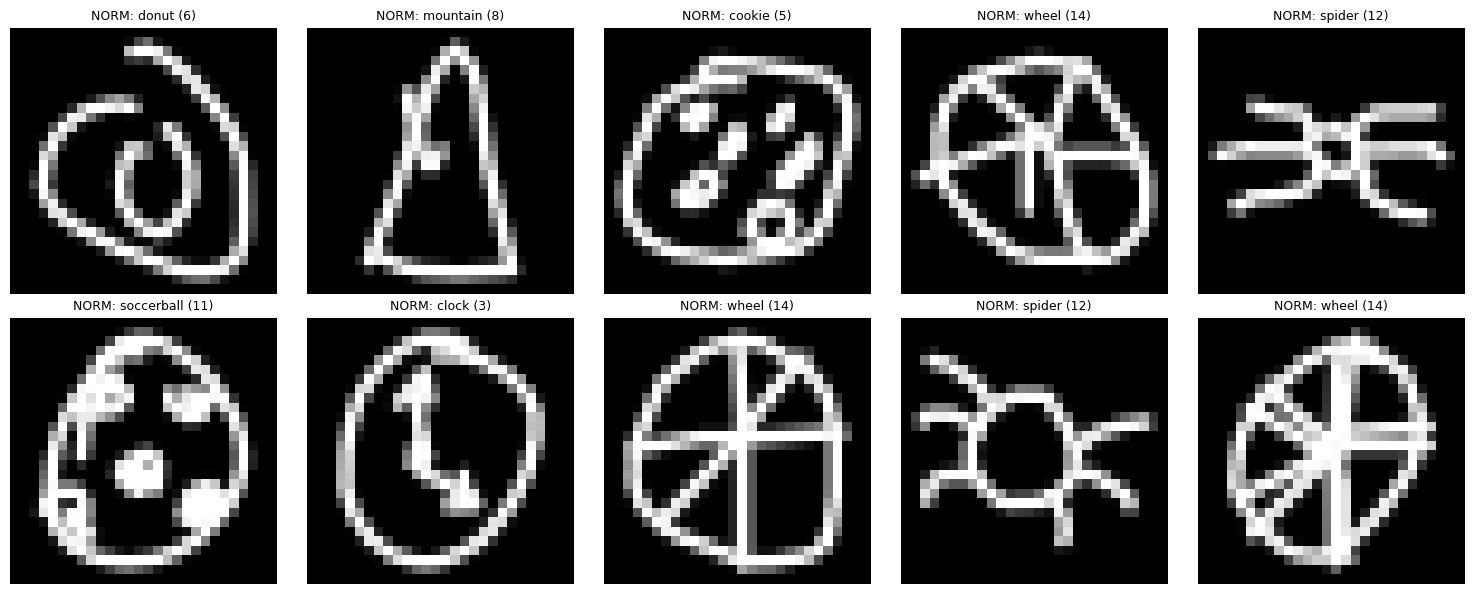

In [8]:
# This block shows random normalized training images with labels.
# It is a quick visual check after preprocessing.
# If labels or brightness look wrong, we can catch issues early.
num_to_show = 10
rng = np.random.default_rng()
random_indices = rng.choice(len(x_train), size=num_to_show, replace=False)

plt.figure(figsize=(15, 6))
for plot_i, sample_idx in enumerate(random_indices):
    img = x_train[sample_idx].reshape(28, 28)
    label_id = int(y_train[sample_idx])
    label_name = str(class_names[label_id])

    plt.subplot(2, 5, plot_i + 1)
    plt.imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
    plt.title(f"NORM: {label_name} ({label_id})", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Here we print basic dataset stats like sample count and feature size.
# It also checks unique class labels in training data.
# This confirms the dataset is ready for modeling.
print(f"Total training samples: {len(x_train)}")
print(f"Total test samples    : {len(x_test)}")
print(f"Feature size per image: {x_train.shape[1]}")
print(f"Unique labels in train: {np.unique(y_train)}")

Total training samples: 60000
Total test samples    : 15000
Feature size per image: 784
Unique labels in train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


# Creating DataLoaders

In [10]:
# This cell defines the custom QuickDrawDataset class.
# It supports both train mode (x,y) and test mode (x only).
# Tensor conversion and scaling are handled inside this class.
class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        self.x = torch.from_numpy(self.x).float() / 255.0
        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [11]:
# Now we create stratified train-validation split using same class ratio.
# After split, dataloaders are built with chosen batch size.
BATCH_SIZE = 128

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

all_idx = np.arange(len(full_train_dataset))
all_labels = full_train_dataset.y.numpy()   

train_idx, val_idx = train_test_split(all_idx, test_size=0.20, random_state=SEED, stratify=all_labels, shuffle=True)

train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_train_dataset, val_idx)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from DL_PA2/DL_PA2/processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [12]:
# In this cell we check dataloader output shapes and batch counts.
# One sample batch is inspected to verify features and labels are correct.
# This avoids silent shape bugs before training starts.
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

xb, yb = next(iter(train_loader))
print("Train batch X:", xb.shape, xb.dtype)
print("Train batch y:", yb.shape, yb.dtype)

Train batches: 375
Val batches  : 94
Train batch X: torch.Size([128, 784]) torch.float32
Train batch y: torch.Size([128]) torch.int64


# Reusable Functions for model Training

In [13]:
# This block defines one-epoch training function.
# It runs forward pass, loss, backward pass, and optimizer update.
# Finally it returns average train loss and train accuracy.
def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()
    individual_loss_sum = 0
    correct_predicted = 0
    total_data = 0

    for each_inputs, each_targets in data_loader:
        each_inputs = each_inputs.to(DEVICE)
        each_targets = each_targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(each_inputs)
        loss = criterion(outputs, each_targets)
        loss.backward()
        optimizer.step()

        individual_loss_sum = individual_loss_sum + loss.item() * each_inputs.size(0)
        correct_predicted = correct_predicted + (torch.max(outputs, 1)[1] == each_targets).sum().item()
        total_data = total_data + each_targets.size(0)

    epoch_loss = individual_loss_sum / total_data
    epoch_accuracy = correct_predicted / total_data
    return epoch_loss, epoch_accuracy

In [14]:
# Here we define evaluation function with no gradient updates.
# Model is switched to eval mode and metrics are computed batch-wise.
def evaluate(model, data_loader, criterion):
    model.eval()
    individual_loss_sum = 0
    correct_predicted = 0
    total_data = 0

    with torch.no_grad():
        for each_inputs, each_targets in data_loader:
            each_inputs = each_inputs.to(DEVICE)
            each_targets = each_targets.to(DEVICE)

            outputs = model(each_inputs)
            loss = criterion(outputs, each_targets)

            individual_loss_sum = individual_loss_sum + loss.item() * each_inputs.size(0)
            correct_predicted = correct_predicted + (torch.max(outputs, 1)[1] == each_targets).sum().item()
            total_data = total_data + each_targets.size(0)

    epoch_loss = individual_loss_sum / total_data
    epoch_accuracy = correct_predicted / total_data
    return epoch_loss, epoch_accuracy

In [15]:
# This helper counts trainable parameters in any model.
# We use it to compare model sizes across parts A, B, and C.
def parameters_count(model):
    total_params = 0
    for p in model.parameters():
        if p.requires_grad:
            total_params = total_params + p.numel()
    return total_params

# Part-A Model

In [16]:
# This cell defines Part A Pancake architecture (shallow and wide).
# Model is initialized and moved to current compute device.
class FCNN(nn.Module):
    def __init__(self, input_dim=784, num_classes=15):
        super(FCNN, self).__init__()
    
        self.fc1 = nn.Linear(input_dim, 1024); 
        self.fc2 = nn.Linear(1024, 1024);      
        self.out = nn.Linear(1024, num_classes)

        self.act1 = nn.ReLU()      
        self.drop = nn.Dropout(0.1)

    def forward(self, x):
        if x.ndim > 2:
            x = x.view(x.size(0), -1)

        x = self.drop(self.act1((self.fc1(x))))
        x = self.drop(self.act1((self.fc2(x))))

        return self.out(x)  

ann_model = FCNN().to(DEVICE)
ann_params = parameters_count(ann_model)
print("FCNN params:", ann_params)
assert ann_params <= 3_000_000, "FCNN model exceeds 3M params"

FCNN params: 1868815


In [17]:
# Now we configure Part A loss, optimizer, and lr scheduler.
# Training loop runs for full epochs and tracks train/val metrics.
# Printed logs help monitor learning and generalization gap.
loss_function_ann = nn.CrossEntropyLoss(label_smoothing=0.1)
EPOCHS_ANN = 40
ann_optimizer = torch.optim.AdamW(ann_model.parameters(), lr=1e-2, weight_decay=1e-4)
ann_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(ann_optimizer, mode="max", factor=0.5, patience=2)

ann_train_losses = []
ann_val_losses = []
ann_train_accs = []
ann_val_accs = []

print("||Part A: FCNN Training||")

for each_epoch in range(EPOCHS_ANN):

    training_loss, training_accuracy = train_one_epoch(ann_model, train_loader, loss_function_ann, ann_optimizer)
    validation_loss, validation_accuracy = evaluate(ann_model, val_loader, loss_function_ann)
    ann_scheduler.step(validation_accuracy)
    
    ann_train_losses.append(training_loss)
    ann_val_losses.append(validation_loss)
    ann_train_accs.append(training_accuracy)
    ann_val_accs.append(validation_accuracy)

    current_lr = ann_optimizer.param_groups[0]["lr"]

    print(f"Epoch [{each_epoch+1}/{EPOCHS_ANN}] | LR {current_lr:.6f} | "
        f"Train Loss {training_loss:.5f}, Train Acc {training_accuracy:.5f} | "
        f"Val Loss {validation_loss:.5f}, Val Acc {validation_accuracy:.5f}")

||Part A: FCNN Training||
Epoch [1/40] | LR 0.010000 | Train Loss 1.63716, Train Acc 0.56881 | Val Loss 1.45360, Val Acc 0.63708
Epoch [2/40] | LR 0.010000 | Train Loss 1.46370, Train Acc 0.63810 | Val Loss 1.42138, Val Acc 0.65567
Epoch [3/40] | LR 0.010000 | Train Loss 1.42818, Train Acc 0.65063 | Val Loss 1.38262, Val Acc 0.66433
Epoch [4/40] | LR 0.010000 | Train Loss 1.40245, Train Acc 0.66285 | Val Loss 1.37179, Val Acc 0.67475
Epoch [5/40] | LR 0.010000 | Train Loss 1.38634, Train Acc 0.67008 | Val Loss 1.36900, Val Acc 0.67017
Epoch [6/40] | LR 0.010000 | Train Loss 1.36462, Train Acc 0.68079 | Val Loss 1.35716, Val Acc 0.67925
Epoch [7/40] | LR 0.010000 | Train Loss 1.35100, Train Acc 0.68573 | Val Loss 1.35226, Val Acc 0.68108
Epoch [8/40] | LR 0.010000 | Train Loss 1.34455, Train Acc 0.68837 | Val Loss 1.33556, Val Acc 0.68850
Epoch [9/40] | LR 0.010000 | Train Loss 1.33550, Train Acc 0.69275 | Val Loss 1.33291, Val Acc 0.69017
Epoch [10/40] | LR 0.010000 | Train Loss 1.3319

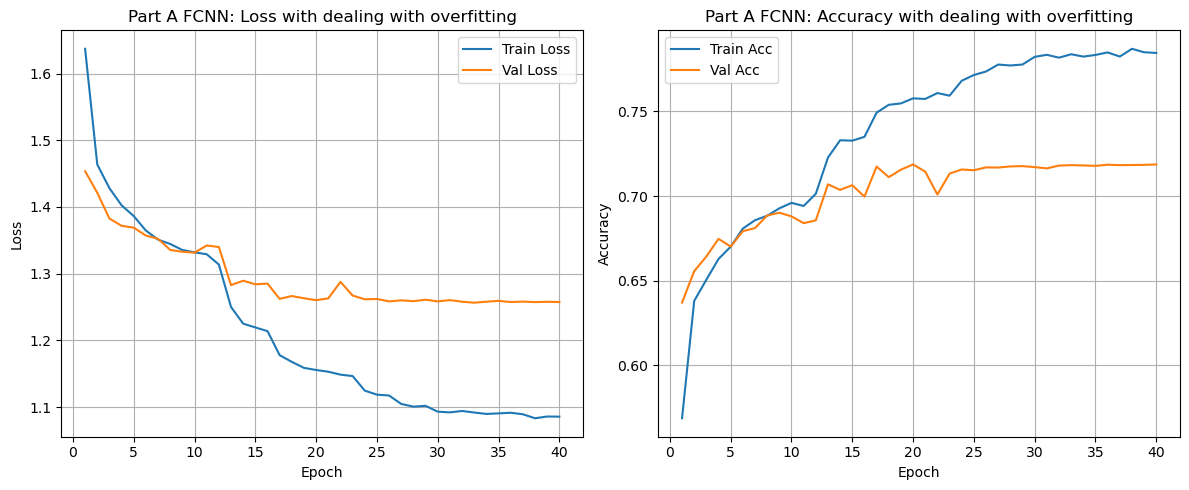

In [18]:
# This block plots Part A training and validation curves.
# Both loss and accuracy trends are shown side by side.
epochs_range_ann = range(1, EPOCHS_ANN + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_ann, ann_train_losses, label="Train Loss")
plt.plot(epochs_range_ann, ann_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part A FCNN: Loss with dealing with overfitting")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_ann, ann_train_accs, label="Train Acc")
plt.plot(epochs_range_ann, ann_val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Part A FCNN: Accuracy with dealing with overfitting")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
# Here we run final evaluation for Part A model.
# Train and validation loss/accuracy are printed together.
ann_train_loss, ann_train_acc = evaluate(ann_model, train_loader, loss_function_ann)
ann_val_loss, ann_val_acc = evaluate(ann_model, val_loader, loss_function_ann)

print(f"FCNN Train Loss: {ann_train_loss:.5f}")
print(f"FCNN Train Acc : {ann_train_acc:.5f}")
print(f"FCNN Val Loss  : {ann_val_loss:.5f}")
print(f"FCNN Val Acc   : {ann_val_acc:.5f}")

FCNN Train Loss: 1.00596
FCNN Train Acc : 0.81181
FCNN Val Loss  : 1.25747
FCNN Val Acc   : 0.71867


# Part-B Model

In [20]:
# This cell defines Part B Tower architecture (deep and narrow).
# It uses repeated hidden layers to test depth-focused learning.
class TowerMLP_Custom(nn.Module):
    def __init__(self, input_dim=784, num_classes=15):
        super(TowerMLP_Custom, self).__init__()

        self.fc1 = nn.Linear(input_dim, 128); self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 128);       self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 128);       self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, 128);       self.bn4 = nn.BatchNorm1d(128)
        self.fc5 = nn.Linear(128, 128);       self.bn5 = nn.BatchNorm1d(128)
        self.fc6 = nn.Linear(128, 128);       self.bn6 = nn.BatchNorm1d(128)
        self.fc7 = nn.Linear(128, 128);       self.bn7 = nn.BatchNorm1d(128)

        self.out = nn.Linear(128, num_classes)
        self.act = nn.LeakyReLU()
        self.drop = nn.Dropout(0.1)

    def forward(self, x):
        if x.ndim > 2:
            x = x.view(x.size(0), -1)

        x = self.drop(self.act(self.bn1(self.fc1(x))))
        x = self.drop(self.act(self.bn2(self.fc2(x))))
        x = self.drop(self.act(self.bn3(self.fc3(x))))
        x = self.drop(self.act(self.bn4(self.fc4(x))))
        x = self.drop(self.act(self.bn5(self.fc5(x))))
        x = self.drop(self.act(self.bn6(self.fc6(x))))
        x = self.drop(self.act(self.bn7(self.fc7(x))))

        return self.out(x)  

tower_model = TowerMLP_Custom().to(DEVICE)
tower_params = parameters_count(tower_model)
print("Tower params:", tower_params)
assert tower_params <= 3_000_000, "Tower model exceeds 3M params"

Tower params: 203279


In [21]:
# Now we set Part B training hyperparameters and scheduler.
# Epoch loop trains tower model and collects all metrics.
loss_function_tower = nn.CrossEntropyLoss(label_smoothing=0.1)
EPOCHS = 40

tower_optimizer = torch.optim.AdamW(tower_model.parameters(),lr=1e-3, weight_decay=1e-4)
tower_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(tower_optimizer, mode="max", factor=0.5, patience=2)

tower_train_losses = []
tower_val_losses = []
tower_train_accs = []
tower_val_accs = []

print("||Part B: Tower MLP Training||")

for each_epoch in range(EPOCHS):
    
    training_loss, training_accuracy = train_one_epoch(tower_model, train_loader, loss_function_tower, tower_optimizer)
    validation_loss, validation_accuracy = evaluate(tower_model, val_loader, loss_function_tower)    
    tower_scheduler.step(validation_accuracy)

    tower_train_losses.append(training_loss)
    tower_val_losses.append(validation_loss)
    tower_train_accs.append(training_accuracy)
    tower_val_accs.append(validation_accuracy)

    current_lr = tower_optimizer.param_groups[0]["lr"]

    print(f"Epoch [{each_epoch+1}/{EPOCHS}] | LR {current_lr:.6f} | "
        f"Train Loss {training_loss:.5f}, Train Acc {training_accuracy:.5f} | "
        f"Val Loss {validation_loss:.5f}, Val Acc {validation_accuracy:.5f}")

||Part B: Tower MLP Training||
Epoch [1/40] | LR 0.001000 | Train Loss 1.62150, Train Acc 0.56110 | Val Loss 1.31605, Val Acc 0.68183
Epoch [2/40] | LR 0.001000 | Train Loss 1.34829, Train Acc 0.67406 | Val Loss 1.24350, Val Acc 0.71033
Epoch [3/40] | LR 0.001000 | Train Loss 1.29035, Train Acc 0.69754 | Val Loss 1.22150, Val Acc 0.72200
Epoch [4/40] | LR 0.001000 | Train Loss 1.24773, Train Acc 0.71696 | Val Loss 1.19053, Val Acc 0.73583
Epoch [5/40] | LR 0.001000 | Train Loss 1.21336, Train Acc 0.73060 | Val Loss 1.19606, Val Acc 0.73325
Epoch [6/40] | LR 0.001000 | Train Loss 1.18730, Train Acc 0.74317 | Val Loss 1.16213, Val Acc 0.74642
Epoch [7/40] | LR 0.001000 | Train Loss 1.16777, Train Acc 0.75010 | Val Loss 1.15762, Val Acc 0.74958
Epoch [8/40] | LR 0.001000 | Train Loss 1.14210, Train Acc 0.76177 | Val Loss 1.14868, Val Acc 0.75600
Epoch [9/40] | LR 0.001000 | Train Loss 1.12611, Train Acc 0.76877 | Val Loss 1.14269, Val Acc 0.75908
Epoch [10/40] | LR 0.001000 | Train Loss 1

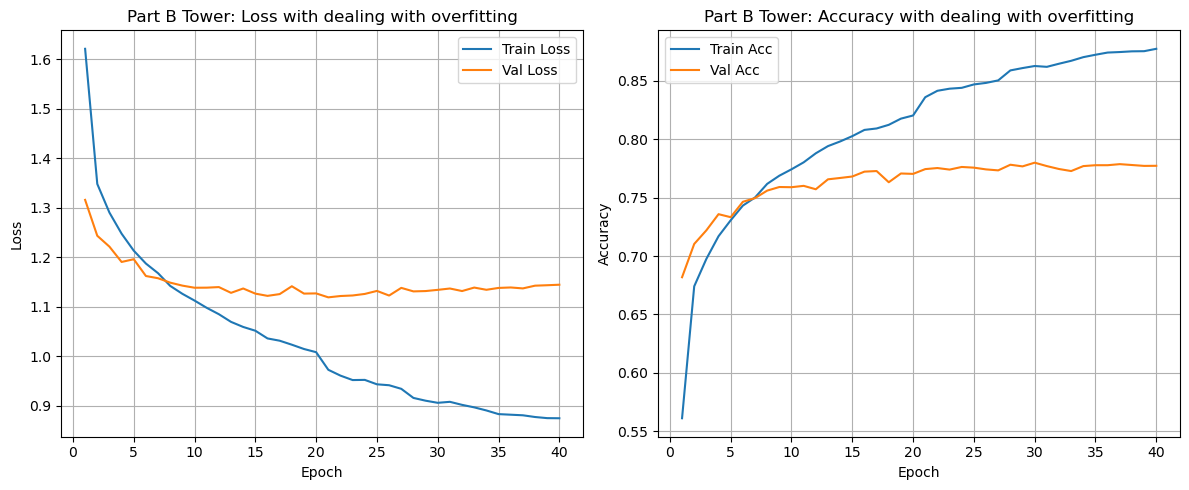

In [22]:
# This block plots Tower train/validation loss and accuracy curves.
# From these curves we can inspect overfitting or underfitting trend.
# Useful for assignment comparison between model families.
epochs_range_tower = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_tower, tower_train_losses, label="Train Loss")
plt.plot(epochs_range_tower, tower_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part B Tower: Loss with dealing with overfitting")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_tower, tower_train_accs, label="Train Acc")
plt.plot(epochs_range_tower, tower_val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Part B Tower: Accuracy with dealing with overfitting")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# Here we evaluate final Part B model on train and validation loaders.
# It prints concise final metrics for reporting.
# These numbers are compared against Part A and Champion.
tower_train_loss, tower_train_acc = evaluate(tower_model, train_loader, loss_function_tower)
tower_val_loss, tower_val_acc = evaluate(tower_model, val_loader, loss_function_tower)

print(f"Tower Train Loss: {tower_train_loss:.5f}")
print(f"Tower Train Acc : {tower_train_acc:.5f}")
print(f"Tower Val Loss  : {tower_val_loss:.5f}")
print(f"Tower Val Acc   : {tower_val_acc:.5f}")

Tower Train Loss: 0.74251
Tower Train Acc : 0.93063
Tower Val Loss  : 1.14452
Tower Val Acc   : 0.77725


# Champion Part Model

In [24]:
# This cell adds optional train-only augmentation pipeline.
# Random affine and random erasing are applied with set probability.
USE_AUGMENTATION = True

train_tfms = transforms.Compose([
    transforms.RandomAffine(degrees=14,                 
        translate=(0.14, 0.14),     
        scale=(0.88, 1.12),         
        shear=10                    
    ),
    transforms.RandomErasing(
        p=0.42,                     
        scale=(0.03, 0.18),         
        ratio=(0.25, 3.8),          
        value=0.0
    ),
])

class TorchvisionAugDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, transform=None, p_apply=0.4):
        self.base_dataset = base_dataset
        self.transform = transform
        self.p_apply = p_apply

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x, y = self.base_dataset[idx]         
        if self.transform is not None and torch.rand(1).item() < self.p_apply:
            img = x.view(1, 28, 28).clone()   
            img = self.transform(img)
            x = img.view(-1)                  
        return x, y

if USE_AUGMENTATION:
    train_dataset_aug = TorchvisionAugDataset(train_dataset, transform=train_tfms, p_apply=0.7)
    train_loader = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    print("Train augmentation: ON")
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    print("Train augmentation: OFF")

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Train augmentation: ON


In [35]:
# Now we define the Champion architecture for final submission model.
# Design is chosen from earlier experiments on width/depth tradeoff.
class Champion(nn.Module):
    def __init__(self, input_dim=784, num_classes=15):
        super(Champion, self).__init__()

        self.fc1 = nn.Linear(input_dim, 512); self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 128);       self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 128);       self.bn3 = nn.BatchNorm1d(128)
        self.out = nn.Linear(128, num_classes)

        self.act_hidden = nn.GELU()
        self.drop = nn.Dropout(0.01)

    def forward(self, x):
        if x.ndim > 2:
            x = x.view(x.size(0), -1)

        x = self.drop(self.act_hidden(self.bn1(self.fc1(x))))
        x = self.drop(self.act_hidden(self.bn2(self.fc2(x))))
        x = self.drop(self.act_hidden(self.bn3(self.fc3(x))))

        return self.out(x)  

champ_model = Champion().to(DEVICE)
champ_params = parameters_count(champ_model)
print("Champion params:", champ_params)
assert champ_params <= 3_000_000, "Champion model exceeds 3M params"


Champion params: 487567


In [36]:
# This is the main Champion training cell with full configuration.
# It trains model, tracks metrics, and updates scheduler each epoch.
# Best checkpoint is saved whenever validation accuracy improves.
ids = [9, 14, 2, 11]   
weights = torch.ones(15, device=DEVICE)
weights[ids] = 1.5      

loss_function_champ = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.03)
print("Weighted classes:", ids)

EPOCHS = 40

champ_optimizer = torch.optim.AdamW(champ_model.parameters(), lr=3e-3, weight_decay=1e-5)
champ_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(champ_optimizer,mode="max",factor=0.5,patience=2)

champ_train_losses = []
champ_val_losses = []
champ_train_accs = []
champ_val_accs = []

best_val_acc = -1.0
best_epoch = -1
best_path = "champ_best.pt"

print("||Champion MLP Training||")

for each_epoch in range(EPOCHS):
    training_loss, training_accuracy = train_one_epoch(champ_model, train_loader, loss_function_champ, champ_optimizer)
    validation_loss, validation_accuracy = evaluate(champ_model, val_loader, loss_function_champ)
    
    champ_scheduler.step(validation_accuracy)

    champ_train_losses.append(training_loss)
    champ_val_losses.append(validation_loss)
    champ_train_accs.append(training_accuracy)
    champ_val_accs.append(validation_accuracy)

    if validation_accuracy > best_val_acc:
        best_val_acc = validation_accuracy
        best_epoch = each_epoch + 1
        torch.save(champ_model.state_dict(), best_path)

    current_lr = champ_optimizer.param_groups[0]["lr"]

    print(f"Epoch [{each_epoch+1}/{EPOCHS}] | LR {current_lr:.6f} | "
        f"Train Loss {training_loss:.5f}, Train Acc {training_accuracy:.5f} | "
        f"Val Loss {validation_loss:.5f}, Val Acc {validation_accuracy:.5f}")

print(f"\nBest Val Acc: {best_val_acc:.5f} at epoch {best_epoch}")
print(f"Best model saved to: {best_path}")

Weighted classes: [9, 14, 2, 11]
||Champion MLP Training||
Epoch [1/40] | LR 0.003000 | Train Loss 1.56831, Train Acc 0.51340 | Val Loss 1.12809, Val Acc 0.67333
Epoch [2/40] | LR 0.003000 | Train Loss 1.34209, Train Acc 0.60198 | Val Loss 1.02309, Val Acc 0.72142
Epoch [3/40] | LR 0.003000 | Train Loss 1.25098, Train Acc 0.63696 | Val Loss 0.98844, Val Acc 0.73775
Epoch [4/40] | LR 0.003000 | Train Loss 1.19456, Train Acc 0.65844 | Val Loss 0.90929, Val Acc 0.76167
Epoch [5/40] | LR 0.003000 | Train Loss 1.14928, Train Acc 0.67577 | Val Loss 0.87861, Val Acc 0.77425
Epoch [6/40] | LR 0.003000 | Train Loss 1.12100, Train Acc 0.68429 | Val Loss 0.86829, Val Acc 0.77767
Epoch [7/40] | LR 0.003000 | Train Loss 1.08705, Train Acc 0.69942 | Val Loss 0.85397, Val Acc 0.78275
Epoch [8/40] | LR 0.003000 | Train Loss 1.06635, Train Acc 0.70515 | Val Loss 0.84397, Val Acc 0.79167
Epoch [9/40] | LR 0.003000 | Train Loss 1.05158, Train Acc 0.71219 | Val Loss 0.81683, Val Acc 0.79700
Epoch [10/40] 

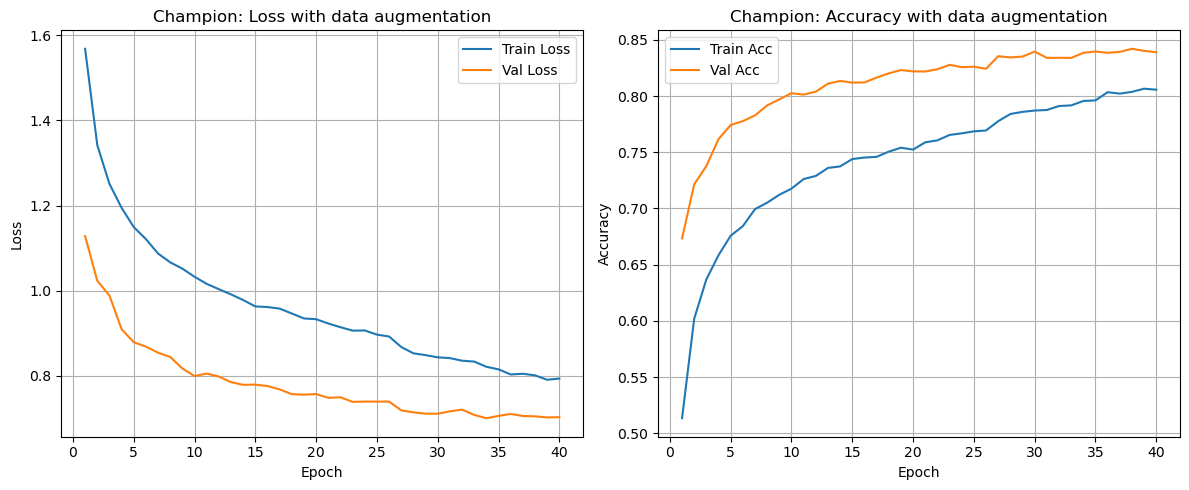

In [37]:
# Here we plot Champion training and validation curves.
# This shows convergence pattern and train-val gap clearly.
# Plots are used later in report rationale section.
epochs_range_champ = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_champ, champ_train_losses, label="Train Loss")
plt.plot(epochs_range_champ, champ_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Champion: Loss with data augmentation")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_champ, champ_train_accs, label="Train Acc")
plt.plot(epochs_range_champ, champ_val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Champion: Accuracy with data augmentation")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [38]:
# This block loads best saved Champion checkpoint from disk.
# After loading, model is moved to device and switched to eval mode.
champ_model.load_state_dict(torch.load("champ_best.pt", map_location=DEVICE))
champ_model.to(DEVICE)
champ_model.eval()

/tmp/ipykernel_54735/479818710.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  champ_model.load_state_dict(torch.load("champ_best.pt", map_location=DEVICE))


Champion(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (out): Linear(in_features=128, out_features=15, bias=True)
  (act_hidden): GELU(approximate='none')
  (drop): Dropout(p=0.01, inplace=False)
)

In [39]:
# In this step we run test inference for leaderboard submission.
# Predicted labels are collected and converted to comma-separated format.
# Final submission.txt is generated for portal upload.
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)

test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

print("Running inference on test set...")
predictions = get_predictions(champ_model, test_loader)

submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from DL_PA2/DL_PA2/processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [40]:
# This helper prints total trainable parameters of current model.
# It also warns if parameter limit is crossed.
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(champ_model)


Model Statistics:
  Total Parameters: 487,567
  ✅ Parameter count is within limits.


In [41]:
# Here we generate Champion predictions on validation set.
# True labels, predicted labels, and images are collected together.
# These arrays are used for confusion analysis in next cells.
champ_model.eval()

all_true = []
all_pred = []
all_x = []

with torch.no_grad():
    for xb, yb in val_loader:
        logits = champ_model(xb.to(DEVICE))
        preds = torch.argmax(logits, dim=1).cpu()

        all_true.extend(yb.numpy())
        all_pred.extend(preds.numpy())
        all_x.extend(xb.numpy())   

all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_x = np.array(all_x)  

print("Validation samples:", len(all_true))
print("Validation accuracy:", (all_true == all_pred).mean())

Validation samples: 12000
Validation accuracy: 0.842


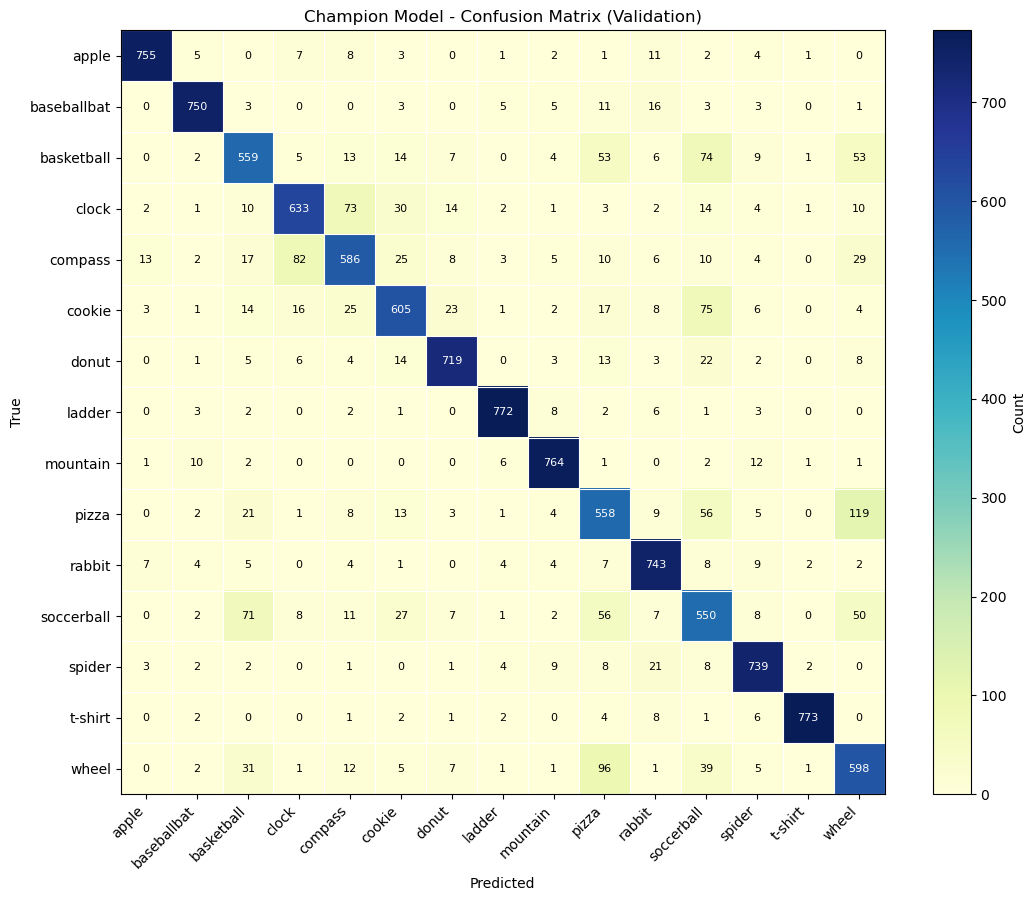

In [42]:
# This cell builds and plots the validation confusion matrix.
# Class labels and per-cell counts are shown for clear reading.
names = [str(n) for n in CLASSES]
num_classes = len(CLASSES)
cm = confusion_matrix(all_true, all_pred, labels=np.arange(num_classes))

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, cmap="YlGnBu")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Count", rotation=90)

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticklabels(names)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Champion Model - Confusion Matrix (Validation)")

ax.set_xticks(np.arange(-0.5, num_classes, 1), minor=True)
ax.set_yticks(np.arange(-0.5, num_classes, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

threshold = cm.max() * 0.5
for i in range(num_classes):
    for j in range(num_classes):
        v = cm[i, j]
        ax.text(j, i, f"{v}", ha="center", va="center",
                color="white" if v > threshold else "black", fontsize=8)

plt.tight_layout()
plt.show()

In [43]:
# Now we compute top confused class pairs from confusion matrix.
# Diagonal is removed and pair confusion is combined both directions.
# Final print gives top pairs with directional counts.
names = [str(n) for n in CLASSES]
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
pair_cm = cm_no_diag + cm_no_diag.T

pairs = []
n = pair_cm.shape[0]
for i in range(n):
    for j in range(i + 1, n):
        pairs.append((int(pair_cm[i, j]), i, j))

pairs.sort(key=lambda x: x[0], reverse=True)
top2 = pairs[:2]

print("Top 2 most confused pairs:")
for rank, (count, i, j) in enumerate(top2, start=1):
    name_i = names[i] if i < len(names) else str(i)
    name_j = names[j] if j < len(names) else str(j)
    
    i_to_j = int(cm[i, j])
    j_to_i = int(cm[j, i])

    print(
        f"{rank}. {name_i} ({i}) <-> {name_j} ({j}) | "
        f"total={count} | {name_i}->{name_j}: {i_to_j}, {name_j}->{name_i}: {j_to_i}")

Top 2 most confused pairs:
1. pizza (9) <-> wheel (14) | total=215 | pizza->wheel: 119, wheel->pizza: 96
2. clock (3) <-> compass (4) | total=155 | clock->compass: 73, compass->clock: 82



Examples for pair: pizza (9) vs wheel (14)


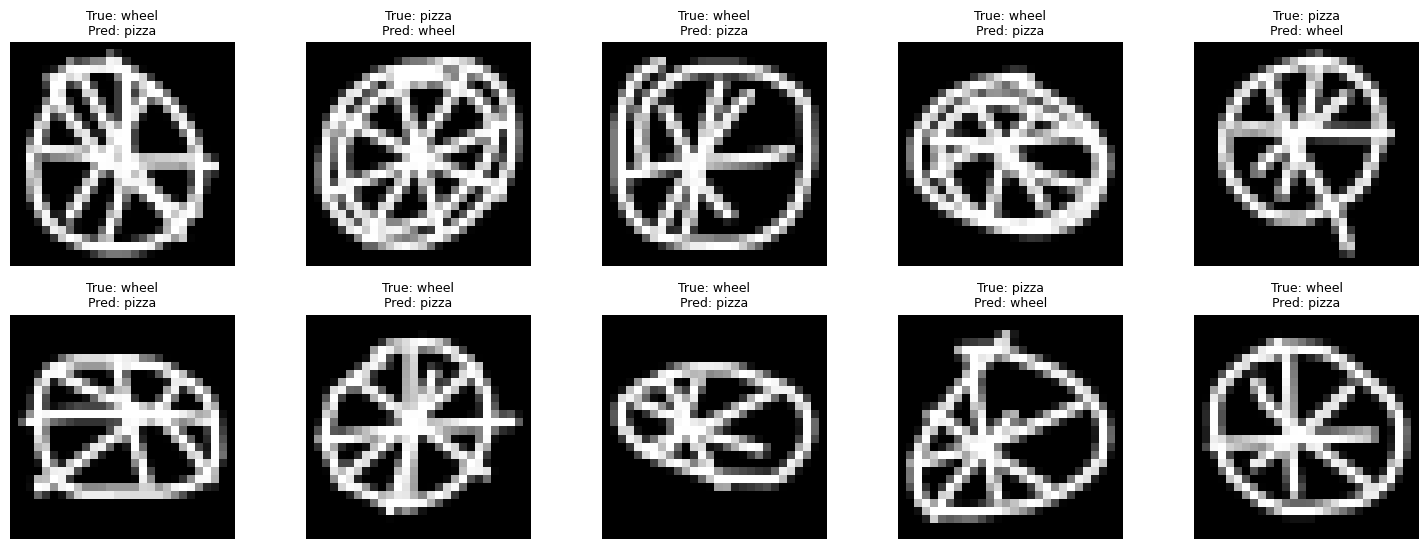


Examples for pair: clock (3) vs compass (4)


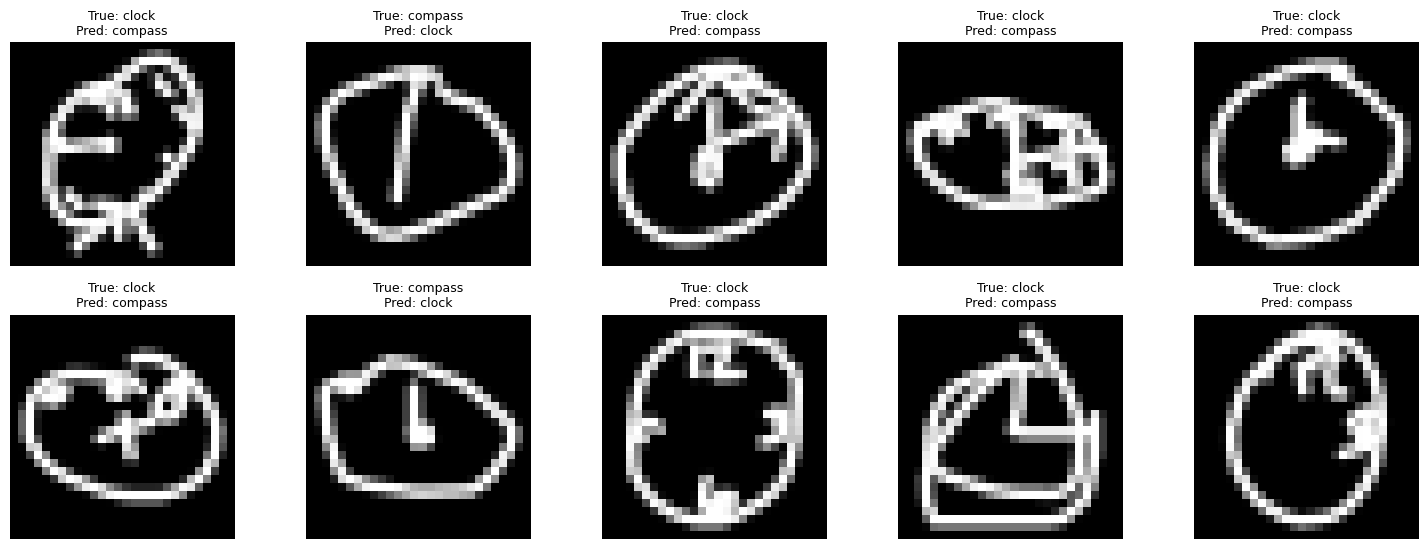

In [44]:
# This cell displays validation examples for top confused pairs.
# Each image shows true label and predicted label side by side.
# It helps explain whether confusion is ambiguity or model limitation.
names = [str(n) for n in CLASSES]

def show_confused_examples(class_a, class_b, max_images):
    idx = np.where(
        ((all_true == class_a) & (all_pred == class_b)) |
        ((all_true == class_b) & (all_pred == class_a))
    )[0]

    if len(idx) == 0:
        print(f"No confused examples found for pair ({class_a}, {class_b}).")
        return

    show_n = min(max_images, len(idx))
    chosen = np.random.choice(idx, size=show_n, replace=False)

    cols = 5
    rows = int(np.ceil(show_n / cols))
    plt.figure(figsize=(3 * cols, 2.8 * rows))

    for k, sample_idx in enumerate(chosen):
        img = all_x[sample_idx].reshape(28, 28)
        t = int(all_true[sample_idx])
        p = int(all_pred[sample_idx])

        t_name = names[t] if t < len(names) else str(t)
        p_name = names[p] if p < len(names) else str(p)

        plt.subplot(rows, cols, k + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"True: {t_name}\nPred: {p_name}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

for _, a, b in top2:
    a_name = names[a] if a < len(names) else str(a)
    b_name = names[b] if b < len(names) else str(b)
    print(f"\nExamples for pair: {a_name} ({a}) vs {b_name} ({b})")
    show_confused_examples(a, b, max_images=10)